In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.decomposition import NMF
from sklearn.datasets import fetch_olivetti_faces
from scipy.io import loadmat
from sklearn.model_selection import train_test_split


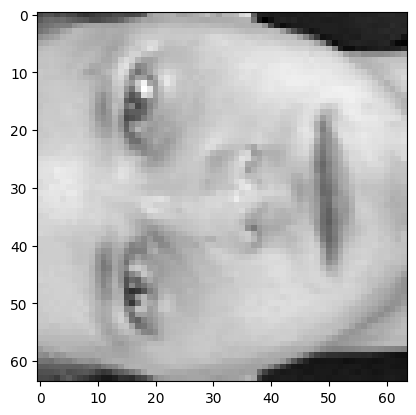

In [2]:
data = loadmat("olivettifaces.mat")
faces = data["faces"]  
X = faces.T  

plt.imshow(X[0].reshape(64, 64), cmap='gray')
plt.show()

In [3]:
y = np.repeat(np.arange(40), 10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print(y.shape)

(400,)


In [7]:
model = NMF(n_components=25, init='nndsvda', random_state=0, max_iter=500)
W_train = model.fit_transform(X_train)  
H = model.components_ 

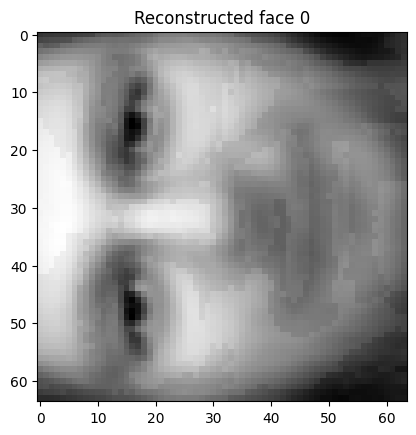

In [8]:
reconstruction = W_train[0] @ H
plt.imshow(reconstruction.reshape(64, 64), cmap='gray')
plt.title("Reconstructed face 0")
plt.show()

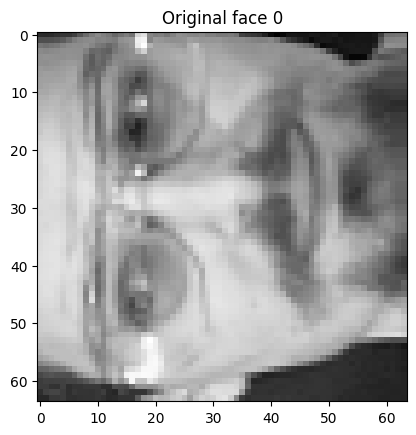

In [9]:
plt.imshow(X_train[0].reshape(64, 64), cmap='gray')
plt.title("Original face 0")
plt.show()

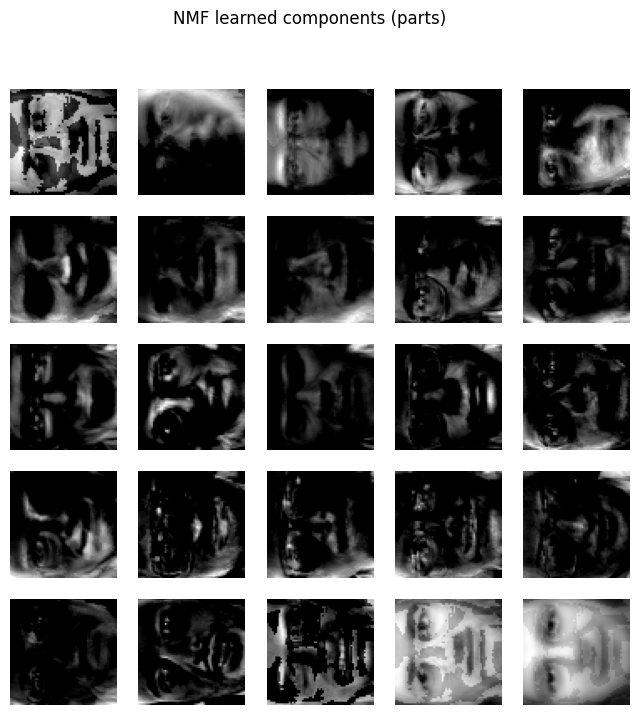

In [10]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(H[i].reshape(64, 64), cmap='gray')
    ax.axis('off')
plt.suptitle("NMF learned components (parts)")
plt.show()